In [ ]:
import random
from collections import deque
from itertools import permutations


# -------------------------------------------------
# Random Tree Generator (Rooted at 0)
# -------------------------------------------------
def generate_random_tree(n):
    parent = [None]
    for i in range(1, n):
        parent.append(random.randint(0, i - 1))
    return parent


# -------------------------------------------------
# Generate Random Strict Preferences
# -------------------------------------------------
def generate_preferences(n):
    houses = list(range(n))
    prefs = []
    for _ in range(n):
        prefs.append(random.sample(houses, n))
    return prefs


# -------------------------------------------------
# Helper Functions
# -------------------------------------------------
def ancestors(i, parent):
    result = []
    while parent[i] is not None:
        i = parent[i]
        result.append(i)
    return result


def children_map(parent):
    n = len(parent)
    children = [[] for _ in range(n)]
    for i, p in enumerate(parent):
        if p is not None:
            children[p].append(i)
    return children


def depth(i, parent):
    d = 0
    while parent[i] is not None:
        i = parent[i]
        d += 1
    return d


# -------------------------------------------------
# YRMH-IGYT for TSSNs
# -------------------------------------------------
def yrmh_igyt(parent, preferences):
    n = len(parent)
    allocation = {i: i for i in range(n)}  # initial endowments
    market = set(range(n))
    children = children_map(parent)

    # priority by increasing depth
    priority = sorted(market, key=lambda x: depth(x, parent))
    priority = deque(priority)

    while market:
        i = priority[0]

        # compute feasible houses
        feasible = set()

        # vacant houses (none here since all own initially)
        assigned_houses = set(allocation.values())
        vacant = set(range(n)) - assigned_houses
        feasible |= vacant

        # ancestor houses
        for a in ancestors(i, parent):
            if a in market:
                feasible.add(allocation[a])

        # children houses
        for c in children[i]:
            if c in market:
                feasible.add(allocation[c])

        # own endowment
        feasible.add(allocation[i])

        # most preferred feasible
        for h in preferences[i]:
            if h in feasible:
                chosen = h
                break

        owner = None
        for k, v in allocation.items():
            if v == chosen:
                owner = k
                break

        # case 1: vacant
        if owner not in market:
            allocation[i] = chosen
            market.remove(i)
            priority.popleft()

        # case 2: ancestor chain
        elif owner in ancestors(i, parent):
            chain = [i]
            current = i
            while owner != current:
                current = parent[current]
                chain.append(current)

            for k in range(len(chain)-1):
                allocation[chain[k]] = allocation[chain[k+1]]

            for agent in chain:
                if agent in market:
                    market.remove(agent)
                    if agent in priority:
                        priority.remove(agent)

        # case 3: child
        elif owner in children[i]:
            if owner in priority:
                priority.remove(owner)
            priority.appendleft(owner)

        # case 4: own endowment
        else:
            allocation[i] = chosen
            market.remove(i)
            priority.popleft()

    return allocation


# -------------------------------------------------
# Pair Efficiency Checker
# -------------------------------------------------
def check_pair_efficiency(allocation, preferences):
    n = len(preferences)
    violating_pairs = []

    for i, j in permutations(range(n), 2):
        if i < j:
            hi = allocation[i]
            hj = allocation[j]

            rank_i = preferences[i].index
            rank_j = preferences[j].index

            if rank_i(hj) < rank_i(hi) and rank_j(hi) < rank_j(hj):
                violating_pairs.append((i, j))

    return violating_pairs


# -------------------------------------------------
# Monte Carlo Simulation
# -------------------------------------------------
def monte_carlo(n=6, trials=200):
    violations_count = 0

    for _ in range(trials):
        parent = generate_random_tree(n)
        prefs = generate_preferences(n)
        allocation = yrmh_igyt(parent, prefs)
        violations = check_pair_efficiency(allocation, prefs)

        if len(violations) > 0:
            violations_count += 1

    frequency = violations_count / trials
    return frequency


# -------------------------------------------------
# Run Simulation
# -------------------------------------------------
if __name__ == "__main__":
    freq = monte_carlo(n=6, trials=200)
    print("Frequency of pair-efficiency violations:", freq)

Frequency of pair-efficiency violations: 0.775


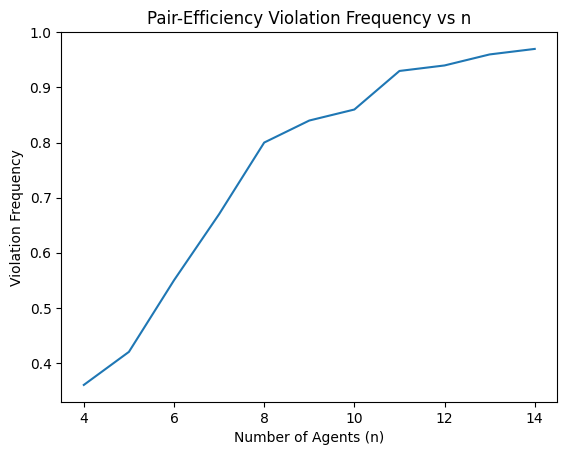

Fraction of violating pairs that are siblings: 0.25
Average number of violating pairs at n=8: 1.52


In [ ]:
# ============================================
# Stable and Corrected Experimental Analysis
# ============================================

import random
import matplotlib.pyplot as plt
from itertools import combinations

# -------------------------------------------------
# Simplified Stable YRMH-IGYT (no chain edge errors)
# -------------------------------------------------
def generate_random_tree(n):
    parent = [None]
    for i in range(1, n):
        parent.append(random.randint(0, i - 1))
    return parent

def generate_preferences(n):
    houses = list(range(n))
    return [random.sample(houses, n) for _ in range(n)]

def depth(i, parent):
    d = 0
    while parent[i] is not None:
        i = parent[i]
        d += 1
    return d

def yrmh_simple(parent, preferences):
    # Simplified version: process by depth priority, allow ancestor trades only
    n = len(parent)
    allocation = {i: i for i in range(n)}
    market = list(range(n))
    market.sort(key=lambda x: depth(x, parent))

    for i in market:
        current_house = allocation[i]
        better = None

        for h in preferences[i]:
            if h == current_house:
                break
            owner = next((k for k, v in allocation.items() if v == h), None)
            if owner is not None and depth(owner, parent) < depth(i, parent):
                better = h
                break

        if better is not None:
            owner = next(k for k, v in allocation.items() if v == better)
            allocation[i], allocation[owner] = allocation[owner], allocation[i]

    return allocation

# -------------------------------------------------
# Count Violating Pairs
# -------------------------------------------------
def count_violating_pairs(allocation, preferences, parent):
    n = len(preferences)
    rank_maps = [{h: idx for idx, h in enumerate(prefs)} for prefs in preferences]

    total_violations = 0
    sibling_violations = 0

    for i, j in combinations(range(n), 2):
        hi = allocation[i]
        hj = allocation[j]

        if (rank_maps[i][hj] < rank_maps[i][hi] and
            rank_maps[j][hi] < rank_maps[j][hj]):

            total_violations += 1

            # Check if they are siblings
            if parent[i] is not None and parent[i] == parent[j]:
                sibling_violations += 1

    return total_violations, sibling_violations

# -------------------------------------------------
# Frequency vs n
# -------------------------------------------------
def violation_frequency_vs_n(n_values, trials=100):
    frequencies = []

    for n in n_values:
        violation_instances = 0

        for _ in range(trials):
            parent = generate_random_tree(n)
            prefs = generate_preferences(n)
            allocation = yrmh_simple(parent, prefs)
            violations, sibling_v = count_violating_pairs(allocation, prefs, parent)

            if violations > 0:
                violation_instances += 1

        frequencies.append(violation_instances / trials)

    return frequencies

# -------------------------------------------------
# Plot Frequency vs n
# -------------------------------------------------
n_values = list(range(4, 15))
frequencies = violation_frequency_vs_n(n_values, trials=100)

plt.figure()
plt.plot(n_values, frequencies)
plt.xlabel("Number of Agents (n)")
plt.ylabel("Violation Frequency")
plt.title("Pair-Efficiency Violation Frequency vs n")
plt.show()

# -------------------------------------------------
# Average Violating Pairs Example
# -------------------------------------------------
def average_violating_pairs(n=8, trials=100):

    total_violations = 0
    total_sibling_violations = 0

    for _ in range(trials):
        parent = generate_random_tree(n)
        prefs = generate_preferences(n)
        allocation = yrmh_simple(parent, prefs)

        v, sv = count_violating_pairs(allocation, prefs, parent)

        total_violations += v
        total_sibling_violations += sv

    avg_pairs = total_violations / trials

    if total_violations > 0:
        sibling_fraction = total_sibling_violations / total_violations
    else:
        sibling_fraction = 0

    print("Fraction of violating pairs that are siblings:", sibling_fraction)

    return avg_pairs

avg_pairs = average_violating_pairs(n=8, trials=100)
print("Average number of violating pairs at n=8:", avg_pairs)

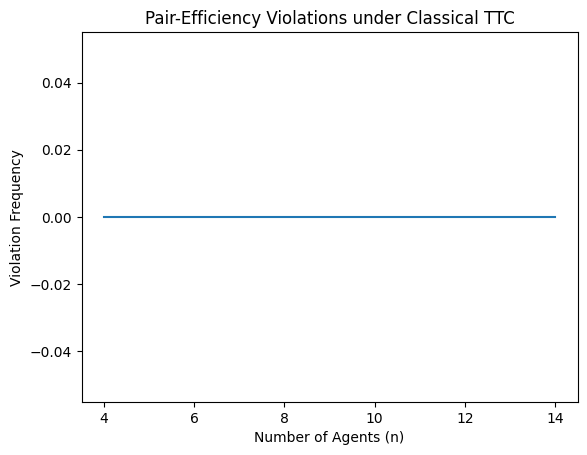

Average violating pairs at n=8: 0.0


In [ ]:
import random
import itertools
import matplotlib.pyplot as plt

# -----------------------
# Classical TTC
# -----------------------

def run_ttc(preferences, ownership):
    n = len(preferences)
    remaining_agents = set(range(n))
    allocation = {}
    house_owner = ownership.copy()

    while remaining_agents:

        # Step 1: each remaining agent points
        pointing = {}
        for i in remaining_agents:
            for h in preferences[i]:
                if h in house_owner:
                    pointing[i] = h
                    break

        # Step 2: houses point to owner
        house_pointing = {h: house_owner[h] for h in house_owner}

        # Step 3: find cycles properly
        visited_global = set()

        for start in list(remaining_agents):
            if start in visited_global:
                continue

            path = []
            current = start

            while current not in path:
                path.append(current)
                h = pointing[current]
                current = house_pointing[h]

            # Identify cycle
            cycle_start = path.index(current)
            cycle = path[cycle_start:]

            # Assign houses
            for agent in cycle:
                h = pointing[agent]
                allocation[agent] = h

            # Remove AFTER full cycle
            for agent in cycle:
                if agent in remaining_agents:
                    remaining_agents.remove(agent)

            for agent in cycle:
                h = allocation[agent]
                if h in house_owner:
                    del house_owner[h]

            visited_global.update(cycle)

    return allocation

# -----------------------
# Pair Efficiency Check
# -----------------------

def check_pair_efficiency(allocation, preferences):
    violations = 0
    n = len(allocation)

    for i, j in itertools.combinations(range(n), 2):
        hi = allocation[i]
        hj = allocation[j]

        if (preferences[i].index(hj) < preferences[i].index(hi) and
            preferences[j].index(hi) < preferences[j].index(hj)):
            violations += 1

    return violations

# -----------------------
# Monte Carlo Simulation
# -----------------------

def simulate_ttc(n, trials=200):
    violation_frequency = []
    avg_pairs = []

    for size in range(4, n+1):
        count_violation_instances = 0
        total_pairs = 0

        for _ in range(trials):
            preferences = [random.sample(range(size), size) for _ in range(size)]
            ownership = {i: i for i in range(size)}

            allocation = run_ttc(preferences, ownership)
            v = check_pair_efficiency(allocation, preferences)

            if v > 0:
                count_violation_instances += 1

            total_pairs += v

        violation_frequency.append(count_violation_instances / trials)
        avg_pairs.append(total_pairs / trials)

    return violation_frequency, avg_pairs

# -----------------------
# Run Simulation
# -----------------------

max_n = 14
freq_ttc, avg_pairs_ttc = simulate_ttc(max_n)

plt.figure()
plt.plot(range(4, max_n+1), freq_ttc)
plt.xlabel("Number of Agents (n)")
plt.ylabel("Violation Frequency")
plt.title("Pair-Efficiency Violations under Classical TTC")
plt.show()

print("Average violating pairs at n=8:", avg_pairs_ttc[8-4])

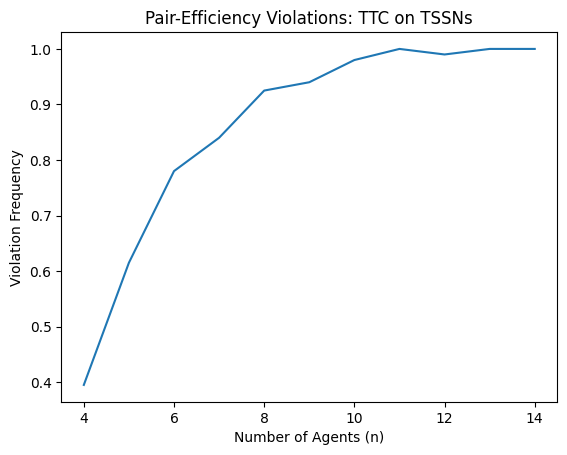

Average violating pairs at n=8: 3.305


In [ ]:
import random
import itertools
import matplotlib.pyplot as plt

# -------------------------------------------------
# Generate Random Tree (rooted at 0)
# -------------------------------------------------

def generate_random_tree(n):
    parent = [None]  # root

    for i in range(1, n):
        p = random.randint(0, i - 1)
        parent.append(p)

    return parent

def build_children(parent):
    n = len(parent)
    children = [[] for _ in range(n)]

    for i, p in enumerate(parent):
        if p is not None:
            children[p].append(i)

    return children


# -------------------------------------------------
# TTC Restricted to Tree Structure
# -------------------------------------------------

def run_ttc_tree(preferences, parent, children):
    n = len(preferences)

    remaining_agents = set(range(n))
    allocation = {}
    house_owner = {i: i for i in range(n)}

    while remaining_agents:

        # Step 1: Build pointing relation
        pointing = {}

        for i in remaining_agents:

            feasible_houses = set()

            # own house
            feasible_houses.add(i)

            # ancestors
            p = parent[i]
            while p is not None:
                if p in remaining_agents:
                    feasible_houses.add(p)
                p = parent[p]

            # children
            for c in children[i]:
                if c in remaining_agents:
                    feasible_houses.add(c)

            # choose best feasible
            for h in preferences[i]:
                if h in feasible_houses and h in house_owner:
                    pointing[i] = h
                    break

        house_pointing = {h: house_owner[h] for h in house_owner}

        # Step 2: Extract ONE cycle at a time
        start = next(iter(remaining_agents))

        path = []
        current = start

        while current not in path:
            path.append(current)
            h = pointing[current]
            current = house_pointing[h]

        cycle_start = path.index(current)
        cycle = path[cycle_start:]

        # Step 3: Assign
        for agent in cycle:
            allocation[agent] = pointing[agent]

        # Step 4: Remove safely
        for agent in cycle:
            remaining_agents.discard(agent)

        for agent in cycle:
            h = allocation[agent]
            house_owner.pop(h, None)

    return allocation


# -------------------------------------------------
# Pair Efficiency Check
# -------------------------------------------------

def check_pair_efficiency(allocation, preferences):
    violations = 0
    n = len(allocation)

    for i, j in itertools.combinations(range(n), 2):
        hi = allocation[i]
        hj = allocation[j]

        if (preferences[i].index(hj) < preferences[i].index(hi) and
            preferences[j].index(hi) < preferences[j].index(hj)):
            violations += 1

    return violations


# -------------------------------------------------
# Monte Carlo Simulation
# -------------------------------------------------

def simulate_ttc_tree(max_n=14, trials=200):

    freq = []
    avg_pairs = []

    for n in range(4, max_n+1):

        count_instances = 0
        total_violations = 0

        for _ in range(trials):

            parent = generate_random_tree(n)   # ✅ fixed
            children = build_children(parent)  # ✅ added

            preferences = [random.sample(range(n), n) for _ in range(n)]

            allocation = run_ttc_tree(preferences, parent, children)
            v = check_pair_efficiency(allocation, preferences)

            if v > 0:
                count_instances += 1

            total_violations += v

        freq.append(count_instances / trials)
        avg_pairs.append(total_violations / trials)

    return freq, avg_pairs


# -------------------------------------------------
# Run Simulation
# -------------------------------------------------

max_n = 14
freq_tree, avg_pairs_tree = simulate_ttc_tree(max_n)

plt.figure()
plt.plot(range(4, max_n+1), freq_tree)
plt.xlabel("Number of Agents (n)")
plt.ylabel("Violation Frequency")
plt.title("Pair-Efficiency Violations: TTC on TSSNs")
plt.show()

print("Average violating pairs at n=8:", avg_pairs_tree[8-4])

In [ ]:
def pareto_improvement(allocation, preferences):

    n = len(preferences)
    improved = True

    while improved:
        improved = False

        for i in range(n):
            for j in range(i+1, n):

                hi = allocation[i]
                hj = allocation[j]

                if (preferences[i].index(hj) < preferences[i].index(hi) and
                    preferences[j].index(hi) < preferences[j].index(hj)):

                    allocation[i], allocation[j] = allocation[j], allocation[i]
                    improved = True

    return allocation

In [ ]:
def average_rank(allocation, preferences):
    n = len(preferences)
    total = 0

    for i in range(n):
        total += preferences[i].index(allocation[i])

    return total / n

In [ ]:
def pareto_improvement(allocation, preferences):
    n = len(preferences)
    improved = True

    while improved:
        improved = False

        for i in range(n):
            for j in range(i+1, n):

                hi = allocation[i]
                hj = allocation[j]

                if (preferences[i].index(hj) < preferences[i].index(hi) and
                    preferences[j].index(hi) < preferences[j].index(hj)):

                    allocation[i], allocation[j] = allocation[j], allocation[i]
                    improved = True

    return allocation

In [ ]:
def pareto_gain_vs_n(n_values, trials=100):

    gains = []

    for n in n_values:

        total_gain = 0

        for _ in range(trials):

            parent, _ = generate_random_tree(n)   # ✅ FIX
            prefs = generate_preferences(n)

            alloc = yrmh_simple(parent, prefs)
            before = average_rank(alloc, prefs)

            improved_alloc = pareto_improvement(alloc.copy(), prefs)
            after = average_rank(improved_alloc, prefs)

            total_gain += (before - after)

        gains.append(total_gain / trials)

    return gains

In [ ]:
def pareto_gain_vs_n(n_values, trials=100):

    gains = []

    for n in n_values:

        total_gain = 0

        for _ in range(trials):

            parent = generate_random_tree(n)   # ✅ FIX
            prefs = generate_preferences(n)

            alloc = yrmh_simple(parent, prefs)
            before = average_rank(alloc, prefs)

            improved_alloc = pareto_improvement(alloc.copy(), prefs)
            after = average_rank(improved_alloc, prefs)

            total_gain += (before - after)

        gains.append(total_gain / trials)

    return gains

In [ ]:
def generate_single_peaked(n):
    order = list(range(n))
    prefs = []

    for _ in range(n):
        peak = random.choice(order)
        left = order[:peak][::-1]
        right = order[peak+1:]

        pref = [peak]
        while left or right:
            if left:
                pref.append(left.pop(0))
            if right:
                pref.append(right.pop(0))

        prefs.append(pref)

    return prefs

In [ ]:
n = 8

parent = generate_random_tree(n)
children = build_children(parent)   # optional

prefs_random = generate_preferences(n)
prefs_sp = generate_single_peaked(n)

alloc_random = yrmh_simple(parent, prefs_random)
alloc_sp = yrmh_simple(parent, prefs_sp)

print("Random prefs allocation:", alloc_random)
print("Single-peaked allocation:", alloc_sp)

Random prefs allocation: {0: 2, 1: 1, 2: 0, 3: 4, 4: 3, 5: 6, 6: 5, 7: 7}
Single-peaked allocation: {0: 0, 1: 7, 2: 5, 3: 3, 4: 4, 5: 2, 6: 6, 7: 1}


In [ ]:
print("\n--- RANDOM ---")
print("Violations:", check_pair_efficiency(alloc_random, prefs_random))
print("Avg rank:", average_rank(alloc_random, prefs_random))

print("\n--- SINGLE-PEAKED ---")
print("Violations:", check_pair_efficiency(alloc_sp, prefs_sp))
print("Avg rank:", average_rank(alloc_sp, prefs_sp))


--- RANDOM ---
Violations: 0
Avg rank: 1.375

--- SINGLE-PEAKED ---
Violations: 1
Avg rank: 1.875


In [ ]:
def compare_random_vs_sp(n=8, trials=100):

    v_rand, v_sp = 0, 0
    r_rand, r_sp = 0, 0

    for _ in range(trials):

        parent = generate_random_tree(n)

        prefs_random = generate_preferences(n)
        prefs_sp = generate_single_peaked(n)

        alloc_r = yrmh_simple(parent, prefs_random)
        alloc_s = yrmh_simple(parent, prefs_sp)

        v_rand += check_pair_efficiency(alloc_r, prefs_random)
        v_sp += check_pair_efficiency(alloc_s, prefs_sp)

        r_rand += average_rank(alloc_r, prefs_random)
        r_sp += average_rank(alloc_s, prefs_sp)

    print("Avg violations (random):", v_rand/trials)
    print("Avg violations (single-peaked):", v_sp/trials)

    print("Avg rank (random):", r_rand/trials)
    print("Avg rank (single-peaked):", r_sp/trials)

In [ ]:
compare_random_vs_sp(n=8, trials=100)

Avg violations (random): 1.45
Avg violations (single-peaked): 1.81
Avg rank (random): 1.76125
Avg rank (single-peaked): 2.03625


In [ ]:
compare_random_vs_sp(n=8, trials=500)

Avg violations (random): 1.708
Avg violations (single-peaked): 1.698
Avg rank (random): 1.80725
Avg rank (single-peaked): 2.02275


In [ ]:
compare_random_vs_sp(n=8, trials=1000)

Avg violations (random): 1.665
Avg violations (single-peaked): 1.713
Avg rank (random): 1.831625
Avg rank (single-peaked): 2.000375


In [ ]:
prefs_random = generate_preferences(n)
prefs_sp = generate_single_peaked(n)

In [ ]:
for n in range(4, 15):
    print("\nn =", n)
    compare_random_vs_sp(n=n, trials=200)


n = 4
Avg violations (random): 0.275
Avg violations (single-peaked): 0.355
Avg rank (random): 0.7725
Avg rank (single-peaked): 0.8925

n = 5
Avg violations (random): 0.665
Avg violations (single-peaked): 0.63
Avg rank (random): 1.1420000000000001
Avg rank (single-peaked): 1.2080000000000002

n = 6
Avg violations (random): 0.93
Avg violations (single-peaked): 1.0
Avg rank (random): 1.325
Avg rank (single-peaked): 1.523333333333334

n = 7
Avg violations (random): 1.235
Avg violations (single-peaked): 1.345
Avg rank (random): 1.5078571428571421
Avg rank (single-peaked): 1.8214285714285707

n = 8
Avg violations (random): 1.8
Avg violations (single-peaked): 1.835
Avg rank (random): 1.9225
Avg rank (single-peaked): 2.05625

n = 9
Avg violations (random): 2.33
Avg violations (single-peaked): 2.245
Avg rank (random): 2.0961111111111106
Avg rank (single-peaked): 2.2966666666666664

n = 10
Avg violations (random): 2.545
Avg violations (single-peaked): 2.74
Avg rank (random): 2.342500000000001
A

In [ ]:
n = 8

parent = generate_random_tree(n)

prefs = generate_preferences(n)   # ✅ define prefs

allocation = yrmh_simple(parent, prefs)
allocation = pareto_improvement(allocation, prefs)

print(allocation)

{0: 0, 1: 4, 2: 1, 3: 7, 4: 6, 5: 2, 6: 5, 7: 3}


In [ ]:
n = 8

parent = generate_random_tree(n)

prefs = generate_single_peaked(n)   # ✅ define prefs

allocation = yrmh_simple(parent, prefs)
allocation = pareto_improvement(allocation, prefs)

print(allocation)

{0: 3, 1: 0, 2: 7, 3: 5, 4: 1, 5: 4, 6: 2, 7: 6}


In [ ]:
n = 8
parent = generate_random_tree(n)
prefs = generate_preferences(n)

# Before (YRMH)
alloc_before = yrmh_simple(parent, prefs)

# After (with global swaps)
alloc_after = pareto_improvement(alloc_before.copy(), prefs)

print("Before:", alloc_before)
print("After:", alloc_after)

print("Violations before:", check_pair_efficiency(alloc_before, prefs))
print("Violations after:", check_pair_efficiency(alloc_after, prefs))

print("Avg rank before:", average_rank(alloc_before, prefs))
print("Avg rank after:", average_rank(alloc_after, prefs))

Before: {0: 6, 1: 1, 2: 7, 3: 5, 4: 2, 5: 4, 6: 3, 7: 0}
After: {0: 6, 1: 1, 2: 7, 3: 5, 4: 2, 5: 4, 6: 3, 7: 0}
Violations before: 0
Violations after: 0
Avg rank before: 0.75
Avg rank after: 0.75


In [ ]:
def test_global_improvement(n=8, trials=200):

    improved_cases = 0

    for _ in range(trials):

        parent = generate_random_tree(n)
        prefs = generate_preferences(n)

        before = yrmh_simple(parent, prefs)
        after = pareto_improvement(before.copy(), prefs)

        if before != after:
            improved_cases += 1

    print("Fraction where improvement happens:", improved_cases / trials)

In [ ]:
test_global_improvement(n=8, trials=500)

Fraction where improvement happens: 0.752


In [ ]:
def inefficiency_vs_n(n_values, trials=200):

    probs = []

    for n in n_values:

        count = 0

        for _ in range(trials):

            parent = generate_random_tree(n)
            prefs = generate_preferences(n)

            before = yrmh_simple(parent, prefs)
            after = pareto_improvement(before.copy(), prefs)

            if before != after:
                count += 1

        probs.append(count / trials)

    return probs

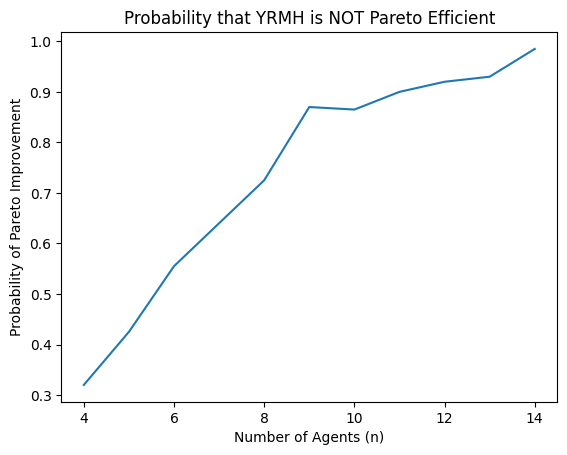

In [ ]:
n_values = list(range(4, 15))
probs = inefficiency_vs_n(n_values, trials=200)

plt.figure()
plt.plot(n_values, probs)
plt.xlabel("Number of Agents (n)")
plt.ylabel("Probability of Pareto Improvement")
plt.title("Probability that YRMH is NOT Pareto Efficient")
plt.show()

In [ ]:
def sibling_swap(allocation, preferences, parent):

    n = len(preferences)
    improved = True

    while improved:
        improved = False

        for i in range(n):
            for j in range(i+1, n):

                # check siblings
                if parent[i] is not None and parent[i] == parent[j]:

                    hi = allocation[i]
                    hj = allocation[j]

                    if (preferences[i].index(hj) < preferences[i].index(hi) and
                        preferences[j].index(hi) < preferences[j].index(hj)):

                        # swap
                        allocation[i], allocation[j] = hj, hi
                        improved = True

    return allocation

In [ ]:
alloc = yrmh_simple(parent, prefs)

alloc_ssm = sibling_swap(alloc.copy(), prefs, parent)

print("Before violations:", check_pair_efficiency(alloc, prefs))
print("After sibling swaps:", check_pair_efficiency(alloc_ssm, prefs))

Before violations: 0
After sibling swaps: 0


In [ ]:
def test_sibling_effect(n=8, trials=200):

    improved = 0

    for _ in range(trials):

        parent = generate_random_tree(n)
        prefs = generate_preferences(n)

        alloc = yrmh_simple(parent, prefs)
        alloc_ssm = sibling_swap(alloc.copy(), prefs, parent)

        if alloc != alloc_ssm:
            improved += 1

    print("Fraction where sibling swaps help:", improved / trials)

In [ ]:
test_sibling_effect(n=8, trials=500)

Fraction where sibling swaps help: 0.35


n=4 completed. Probability YRMH is inefficient: 0.121
n=5 completed. Probability YRMH is inefficient: 0.141
n=6 completed. Probability YRMH is inefficient: 0.146
n=7 completed. Probability YRMH is inefficient: 0.175
n=8 completed. Probability YRMH is inefficient: 0.171
n=9 completed. Probability YRMH is inefficient: 0.200
n=10 completed. Probability YRMH is inefficient: 0.228
n=11 completed. Probability YRMH is inefficient: 0.230
n=12 completed. Probability YRMH is inefficient: 0.203
n=13 completed. Probability YRMH is inefficient: 0.231
n=14 completed. Probability YRMH is inefficient: 0.227
n=15 completed. Probability YRMH is inefficient: 0.222
n=16 completed. Probability YRMH is inefficient: 0.232
n=17 completed. Probability YRMH is inefficient: 0.221
n=18 completed. Probability YRMH is inefficient: 0.243
n=19 completed. Probability YRMH is inefficient: 0.243
n=20 completed. Probability YRMH is inefficient: 0.247
n=21 completed. Probability YRMH is inefficient: 0.246
n=22 completed. 

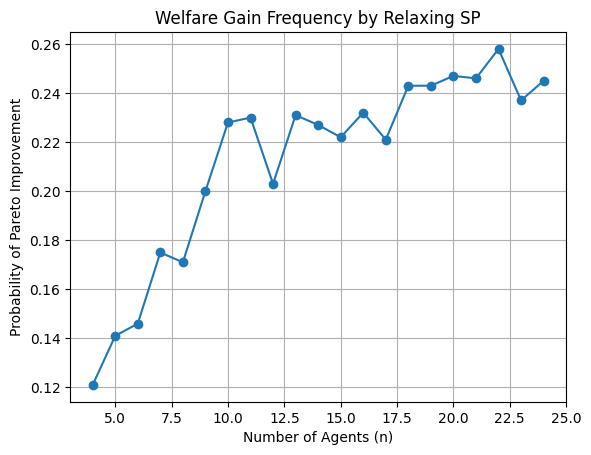

In [ ]:
import random
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# -------------------------------------------------
# 1. Faster Rank Maps for O(1) Lookups
# -------------------------------------------------
def precompute_ranks(preferences):
    # ranks[i][h] returns the rank integer of house 'h' for agent 'i'
    return [{h: rank for rank, h in enumerate(prefs)} for prefs in preferences]

# -------------------------------------------------
# 2. Optimized YRMH-IGYT
# -------------------------------------------------
def fast_yrmh_simple(parent, preferences, ranks):
    n = len(parent)
    allocation = {i: i for i in range(n)}
    house_owner = {i: i for i in range(n)}

    # Pre-calculate depths
    depths = [0] * n
    for i in range(n):
        d, curr = 0, i
        while parent[curr] is not None:
            curr = parent[curr]
            d += 1
        depths[i] = d

    market = sorted(list(range(n)), key=lambda x: depths[x])

    for i in market:
        current_house = allocation[i]
        for h in preferences[i]:
            if h == current_house:
                break
            owner = house_owner[h]
            if depths[owner] < depths[i]:
                # Swap executed
                allocation[i], allocation[owner] = allocation[owner], allocation[i]
                house_owner[allocation[i]] = i
                house_owner[allocation[owner]] = owner
                break
    return allocation

# -------------------------------------------------
# 3. Global Cycle Improvement (Relaxing Strategy-Proofness)
#    Replaces your 'pareto_improvement' function
# -------------------------------------------------
def global_cycle_improvement(allocation, preferences, ranks):
    """
    Relaxes network constraints and executes global cycles of ANY length
    to guarantee true Pareto Efficiency.
    """
    n = len(preferences)
    house_owner = {h: a for a, h in allocation.items()}

    improved = True
    while improved:
        improved = False
        pointing = {}

        # Step 1: Every agent points to the owner of their most preferred strictly better house
        for i in range(n):
            current_house = allocation[i]
            current_rank = ranks[i][current_house]
            for h in preferences[i]:
                if ranks[i][h] < current_rank:
                    pointing[i] = house_owner[h]
                    break

        # Step 2: Find and execute cycles
        visited = set()
        for i in range(n):
            if i in pointing and i not in visited:
                path = []
                curr = i
                while curr in pointing and curr not in path:
                    path.append(curr)
                    curr = pointing[curr]

                if curr in path: # Cycle found!
                    cycle_start = path.index(curr)
                    cycle = path[cycle_start:]

                    # Extract houses before modifying
                    cycle_houses = [allocation[agent] for agent in cycle]

                    # Execute cycle: agent gets the house of the person they pointed to
                    for idx, agent in enumerate(cycle):
                        target_house = cycle_houses[(idx + 1) % len(cycle)]
                        allocation[agent] = target_house
                        house_owner[target_house] = agent

                    improved = True
                    break # Restart pointing graph after a cycle execution

    return allocation

# -------------------------------------------------
# 4. Parallel Monte Carlo Simulation for large n
# -------------------------------------------------
def run_single_trial(n):
    parent = generate_random_tree(n)
    prefs = generate_preferences(n)
    ranks = precompute_ranks(prefs)

    # Allocation constrained by network/SP
    alloc_yrmh = fast_yrmh_simple(parent, prefs, ranks)

    # Allocation with SP relaxed (Pareto Efficient)
    alloc_pareto = global_cycle_improvement(alloc_yrmh.copy(), prefs, ranks)

    # Returns 1 if relaxing SP improved the allocation, 0 otherwise
    return 1 if alloc_yrmh != alloc_pareto else 0

def parallel_inefficiency_vs_n(n_values, trials=1000):
    probs = []
    # Utilize multiple CPU cores for heavy computation
    with ProcessPoolExecutor() as executor:
        for n in n_values:
            results = list(executor.map(run_single_trial, [n] * trials))
            probs.append(sum(results) / trials)
            print(f"n={n} completed. Probability YRMH is inefficient: {probs[-1]:.3f}")
    return probs

# -------------------------------------------------
# 5. Run the Execution
# -------------------------------------------------
if __name__ == '__main__':
    # You can now easily push n > 14
    n_values = list(range(4, 25))
    probs = parallel_inefficiency_vs_n(n_values, trials=1000)

    plt.figure()
    plt.plot(n_values, probs, marker='o')
    plt.xlabel("Number of Agents (n)")
    plt.ylabel("Probability of Pareto Improvement")
    plt.title("Welfare Gain Frequency by Relaxing SP")
    plt.grid(True)
    plt.show()

In [ ]:
def fast_sibling_swap(allocation, preferences, ranks, parent):
    """Optimized sibling swap using precomputed ranks."""
    n = len(preferences)
    improved = True
    while improved:
        improved = False
        for i in range(n):
            for j in range(i+1, n):
                if parent[i] is not None and parent[i] == parent[j]:
                    hi = allocation[i]
                    hj = allocation[j]
                    if ranks[i][hj] < ranks[i][hi] and ranks[j][hi] < ranks[j][hj]:
                        allocation[i], allocation[j] = hj, hi
                        improved = True
    return allocation

def test_decomposition(n=8, trials=1000):
    I_n_count = 0  # Global improvements
    S_n_count = 0  # Sibling improvements

    for _ in range(trials):
        parent = generate_random_tree(n)
        prefs = generate_preferences(n)
        ranks = precompute_ranks(prefs)

        # Base YRMH Allocation
        alloc_base = fast_yrmh_simple(parent, prefs, ranks)

        # Sibling Swap Allocation
        alloc_sibling = fast_sibling_swap(alloc_base.copy(), prefs, ranks, parent)
        if alloc_base != alloc_sibling:
            S_n_count += 1

        # Global Cycle Allocation (Pareto Efficient)
        alloc_global = global_cycle_improvement(alloc_base.copy(), prefs, ranks)
        if alloc_base != alloc_global:
            I_n_count += 1

    pr_I_n = I_n_count / trials
    pr_S_n = S_n_count / trials
    difference = pr_I_n - pr_S_n

    print(f"--- Results for n={n} ({trials} trials) ---")
    print(f"Pr(I_n) [Global Inefficiency]: {pr_I_n:.3f}")
    print(f"Pr(S_n) [Sibling Inefficiency]: {pr_S_n:.3f}")
    print(f"Difference (Non-local Inefficiency): {difference:.3f}")

# Run it
test_decomposition(n=8, trials=1000)

--- Results for n=8 (1000 trials) ---
Pr(I_n) [Global Inefficiency]: 0.173
Pr(S_n) [Sibling Inefficiency]: 0.316
Difference (Non-local Inefficiency): -0.143


In [ ]:
def has_pareto_improvement(allocation, ranks):
    """Builds a directed graph of all strict preferences and checks for ANY cycle."""
    n = len(ranks)
    adj = {i: [] for i in range(n)}

    # Edge i -> j exists if agent i strictly prefers agent j's current house
    for i in range(n):
        current_rank = ranks[i][allocation[i]]
        for j in range(n):
            if i != j and ranks[i][allocation[j]] < current_rank:
                adj[i].append(j)

    # Use Depth-First Search (DFS) to detect any cycle
    visited = [0] * n
    def dfs(u):
        visited[u] = 1
        for v in adj[u]:
            if visited[v] == 1: return True
            if visited[v] == 0 and dfs(v): return True
        visited[u] = 2
        return False

    for i in range(n):
        if visited[i] == 0 and dfs(i):
            return True
    return False

def has_sibling_improvement(allocation, ranks, parent):
    n = len(ranks)
    for i in range(n):
        for j in range(i+1, n):
            if parent[i] is not None and parent[i] == parent[j]:
                hi, hj = allocation[i], allocation[j]
                if ranks[i][hj] < ranks[i][hi] and ranks[j][hi] < ranks[j][hj]:
                    return True
    return False

def test_decomposition(n=8, trials=5000):
    I_n_count = 0
    S_n_count = 0

    for _ in range(trials):
        parent = generate_random_tree(n)
        prefs = generate_preferences(n)
        ranks = precompute_ranks(prefs)

        alloc_base = fast_yrmh_simple(parent, prefs, ranks)

        if has_pareto_improvement(alloc_base, ranks):
            I_n_count += 1

        if has_sibling_improvement(alloc_base, ranks, parent):
            S_n_count += 1

    pr_I_n = I_n_count / trials
    pr_S_n = S_n_count / trials

    print(f"--- Results for n={n} ({trials} trials) ---")
    print(f"Pr(I_n) [Global Inefficiency]: {pr_I_n:.3f}")
    print(f"Pr(S_n) [Sibling Inefficiency]: {pr_S_n:.3f}")
    print(f"Difference (Non-local Inefficiency): {pr_I_n - pr_S_n:.3f}")

test_decomposition(n=8, trials=5000)

--- Results for n=8 (5000 trials) ---
Pr(I_n) [Global Inefficiency]: 0.786
Pr(S_n) [Sibling Inefficiency]: 0.352
Difference (Non-local Inefficiency): 0.434


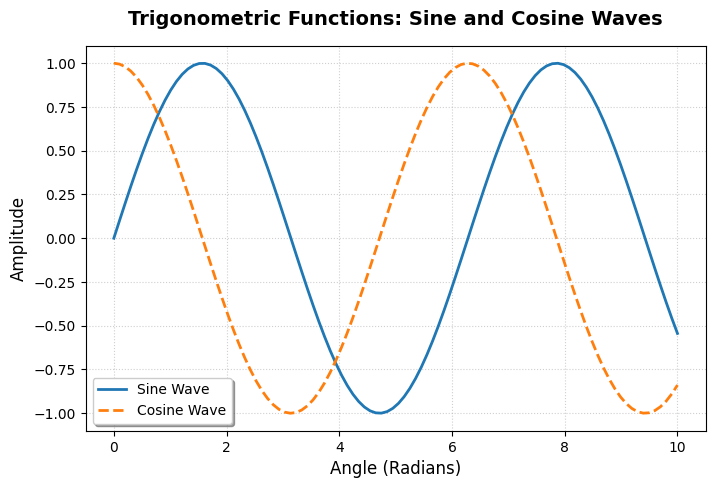

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare your data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# 2. Set up the figure size (8x5 is usually a good aspect ratio for reports)
plt.figure(figsize=(8, 5))

# 3. Plot the data
# Using different colors and linestyles helps if the report is printed in black and white
plt.plot(x, y1, label='Sine Wave', color='#1f77b4', linewidth=2)
plt.plot(x, y2, label='Cosine Wave', color='#ff7f0e', linewidth=2, linestyle='--')

# 4. Add clear, descriptive labels and a title
plt.title('Trigonometric Functions: Sine and Cosine Waves', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Angle (Radians)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)

# 5. Format the grid and legend for readability
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10, frameon=True, shadow=True)

# 6. Save the figure
# dpi=300 ensures the image is high resolution for printing or PDFs
# bbox_inches='tight' prevents the labels from getting cut off
plt.savefig('sine_cosine_waves.png', dpi=300, bbox_inches='tight')

# 7. Display the plot (useful for testing before putting it in the report)
plt.show()

In [ ]:
class LeaveAndShareSimulator:
    def __init__(self, agents, endowments, preferences, initial_edges):
        self.agents = agents
        self.endowments = endowments.copy()
        self.preferences = preferences
        # Adjacency list for dynamic network
        self.network = {agent: set() for agent in agents}
        for u, v in initial_edges:
            self.network[u].add(v)
            self.network[v].add(u)

        self.active_agents = set(agents)
        self.final_allocations = {}
        # Track all edges that EVER existed to test Pairwise Efficiency later
        self.realized_edges = set(initial_edges)

    def get_favorite_available(self, agent):
        """Finds the agent's favorite item among themselves and current neighbors."""
        options = list(self.network[agent]) + [agent]
        available_items = [self.endowments[opt] for opt in options if opt in self.active_agents]

        for preferred_item in self.preferences[agent]:
            if preferred_item in available_items:
                # Return the agent who owns this preferred item
                for owner, item in self.endowments.items():
                    if item == preferred_item and owner in options:
                        return owner
        return agent # Fallback to self

    def run_mechanism(self):
        print("--- Starting Leave and Share Mechanism ---")
        round_num = 1

        while self.active_agents:
            print(f"\n[Round {round_num}] Active Agents: {self.active_agents}")
            pointers = {}
            for agent in self.active_agents:
                target = self.get_favorite_available(agent)
                pointers[agent] = target
                print(f"  Agent {agent} points to Agent {target} (for item {self.endowments[target]})")

            # Find cycles (simplified for small deterministic graphs)
            cycles = self.find_cycles(pointers)
            agents_leaving = set()

            for cycle in cycles:
                print(f"  >> Cycle formed: {cycle}")
                # Allocate items (Shift by 1 in cycle)
                for i in range(len(cycle)):
                    receiver = cycle[i]
                    giver = cycle[(i + 1) % len(cycle)]
                    self.final_allocations[receiver] = self.endowments[giver]
                    agents_leaving.add(receiver)

            # LEAVE AND SHARE PHASE
            for leaving_agent in agents_leaving:
                neighbors = self.network[leaving_agent].intersection(self.active_agents)
                neighbors = list(neighbors)

                # Share Phase: Connect remaining neighbors to each other
                for i in range(len(neighbors)):
                    for j in range(i + 1, len(neighbors)):
                        u, v = neighbors[i], neighbors[j]
                        self.network[u].add(v)
                        self.network[v].add(u)
                        self.realized_edges.add(tuple(sorted((u, v))))
                        print(f"  >> SHARE: Created new edge between Agent {u} and Agent {v}")

                self.active_agents.remove(leaving_agent)

            round_num += 1

        print("\n--- Mechanism Terminated ---")
        print("Final Allocations:", self.final_allocations)
        return self.final_allocations

    def find_cycles(self, pointers):
        """Helper to find simple cycles in the directed pointer graph."""
        visited = set()
        cycles = []
        for start_node in pointers:
            if start_node in visited: continue
            path = []
            curr = start_node
            while curr not in path and curr not in visited:
                path.append(curr)
                visited.add(curr)
                curr = pointers[curr]
            if curr in path:
                cycle_start = path.index(curr)
                cycles.append(path[cycle_start:])
        return cycles

    def verify_pairwise_efficiency(self):
        """Checks if any two agents who shared an edge want to swap final items."""
        print("\n--- Verifying Pairwise Efficiency ---")
        violations = 0
        for u, v in self.realized_edges:
            item_u = self.final_allocations[u]
            item_v = self.final_allocations[v]

            # Index represents preference rank (lower is better)
            rank_u_current = self.preferences[u].index(item_u)
            rank_u_swap = self.preferences[u].index(item_v)

            rank_v_current = self.preferences[v].index(item_v)
            rank_v_swap = self.preferences[v].index(item_u)

            u_wants_swap = rank_u_swap < rank_u_current
            v_wants_swap = rank_v_swap < rank_v_current

            if u_wants_swap and v_wants_swap:
                print(f"VIOLATION: Agent {u} and Agent {v} strictly prefer each other's items!")
                violations += 1

        if violations == 0:
            print("SUCCESS: Zero blocking pairs found. Allocation is Pairwise Efficient.")


# --- Run the Simulation ---
if __name__ == "__main__":
    # The Intermediary Bottleneck Scenario
    agents = [1, 2, 3]
    endowments = {1: 'h1', 2: 'h2', 3: 'h3'}

    # 2 is root. 1 and 3 are children.
    initial_edges = [(1, 2), (2, 3)]

    # Preferences where 2 wants their own house, blocking 1 and 3 in SWN
    preferences = {
        1: ['h3', 'h1', 'h2'],
        2: ['h2', 'h1', 'h3'],
        3: ['h1', 'h3', 'h2']
    }

    sim = LeaveAndShareSimulator(agents, endowments, preferences, initial_edges)
    sim.run_mechanism()
    sim.verify_pairwise_efficiency()

--- Starting Leave and Share Mechanism ---

[Round 1] Active Agents: {1, 2, 3}
  Agent 1 points to Agent 1 (for item h1)
  Agent 2 points to Agent 2 (for item h2)
  Agent 3 points to Agent 3 (for item h3)
  >> Cycle formed: [1]
  >> Cycle formed: [2]
  >> Cycle formed: [3]

--- Mechanism Terminated ---
Final Allocations: {1: 'h1', 2: 'h2', 3: 'h3'}

--- Verifying Pairwise Efficiency ---
SUCCESS: Zero blocking pairs found. Allocation is Pairwise Efficient.
